In [11]:
from pathlib import Path
import pandas as pd

In [12]:
#things we might also need 
from pre_processing.labeling import detect_spikes, init_label, plot_signal_peaks, extract_activity_windows, apply_corrected_labels, extract_pressure_data, remove_idle, sort_push_pull
from pre_processing.fiks_time_muse import make_df, check_samples, fix_time_muse_hz
from pre_processing.clean_mitch_timestamps import remove_end_duplicates, add_ReconstructedTime
from pre_processing.filter_sensor_data import median_filter_medfilt
from pre_processing.segment_repetition_vol2 import plot_activity_accelerations_peaks_and_magnitude, get_start_stop_times_from_peaks, assign_rep_ids
from plotting.plot_sensor_signals import plot_all_sensors, plot_fsr, plot_single_imu
from utils import get_imu_cols, get_fsr_cols

First get all relevant files:

In [13]:
test_directory = Path(r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_johanne\test_14")

# combined and fully preprocessed files
rarm_old_finished = test_directory / "Muse_E2511_RED-arm_comined_ppsorted_add_rep_ids_cleaned.csv"
lback_old_finished = test_directory / "Muse_E2511_GREY-back_combined_ppsorted_add_rep_ids_cleaned.csv"
lsole_old_finished = test_directory / "mitch_B0308-big-left_combined_ppsorted_drop_imu_add_rep_ids_cleaned.csv"
rsole_old_finished = test_directory / "mitch_B0510-big-right_combined_ppsorted_drop_imu_add_rep_ids_cleaned.csv"

# raw session 1 files (omits the squatting activity)
rarm_raw_1 = test_directory / "Muse_E2511_RED-arm_session1.txt"
lback_raw_1 = test_directory / "Muse_E2511_GREY-back_session1.txt"
lsole_raw_1 = test_directory / "mitch_B0308-big_left_session_1.txt"
rsole_raw_1 = test_directory / "mitch_B0510-big_right_session_1.txt"


# raw session 2 files (recording stops between squatting and lifting) i.e strategy is use start of second recording and end of first slay
rarm_raw_2 = test_directory / "Muse_E2511_RED-arm_session2.txt"
lback_raw_2 = test_directory / "Muse_E2511_GREY-back_session2.txt"
lsole_raw_2 = test_directory / "mitch_B0308-left_session2.txt"
rsole_raw_2 = test_directory / "mitch_B0510-right_session2.txt"

dfs_session1 = make_df(muse_file_1=str(rarm_raw_1), muse_file_2=str(lback_raw_1), mitch_file_1=str(lsole_raw_1), mitch_file_2=str(rsole_raw_1))
dfs_session2 = make_df(muse_file_1=str(rarm_raw_2), muse_file_2=str(lback_raw_2), mitch_file_1=str(lsole_raw_2), mitch_file_2=str(rsole_raw_2))

# ---------------- OLD FINISHED FILES ----------------
df_rarm_old_finished = pd.read_csv(rarm_old_finished)
df_lback_old_finished = pd.read_csv(lback_old_finished)
df_lsole_old_finished = pd.read_csv(lsole_old_finished)
df_rsole_old_finished = pd.read_csv(rsole_old_finished)




In [14]:
fixed_time_rarm1 = fix_time_muse_hz(dfs_session1, 0, str(rarm_raw_1), 800)# 800 is the sampling frequency
fixed_time_lback1 = fix_time_muse_hz(dfs_session1, 1, str(lback_raw_1), 800) # 800 is the sampling frequency


fixed_time_rarm2 = fix_time_muse_hz(dfs_session2, 0, str(rarm_raw_2), 800)# 800 is the sampling frequency
fixed_time_lback2 = fix_time_muse_hz(dfs_session2, 1, str(lback_raw_2), 800) # 800 is the sampling frequency


# soles too
df_dupli_left1, outpath_dupli_left1 = remove_end_duplicates(str(lsole_raw_1))
df_dupli_right1, outpath_dupli_right1 = remove_end_duplicates(str(rsole_raw_1))
df_time_left1, outpath_time_left1 = add_ReconstructedTime(outpath_dupli_left1, df_dupli_left1)
df_time_right1, outpath_time_right1 = add_ReconstructedTime(outpath_dupli_right1, df_dupli_right1)

df_dupli_left2, outpath_dupli_left2 = remove_end_duplicates(str(lsole_raw_2))
df_dupli_right2, outpath_dupli_right2 = remove_end_duplicates(str(rsole_raw_2))
df_time_left2, outpath_time_left2 = add_ReconstructedTime(outpath_dupli_left2, df_dupli_left2)
df_time_right2, outpath_time_right2 = add_ReconstructedTime(outpath_dupli_right2, df_dupli_right2)




read filepath: C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_johanne\test_14\mitch_B0308-big_left_session_1.txt
output path C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_johanne\test_14\mitch_B0308-big_left_session_1_del_end_dupli.csv
read filepath: C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_johanne\test_14\mitch_B0510-big_right_session_1.txt
output path C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_johanne\test_14\mitch_B0510-big_right_session_1_del_end_dupli.csv
Sample number: 62991
Recorded time sec: 614.747
Recorded time min: 10.245783333333334
Sample number: 62971
Recorded time sec: 614.551
Recorded time min: 10.242516666666667
read filepath: C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_johanne\test_14\mitch_B0308-left_session2.txt
output path C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_johanne\test_14\mitch_B0308-left_session2_del_end_dupli.csv
read filepath: C:\Users\Bruker\Mast

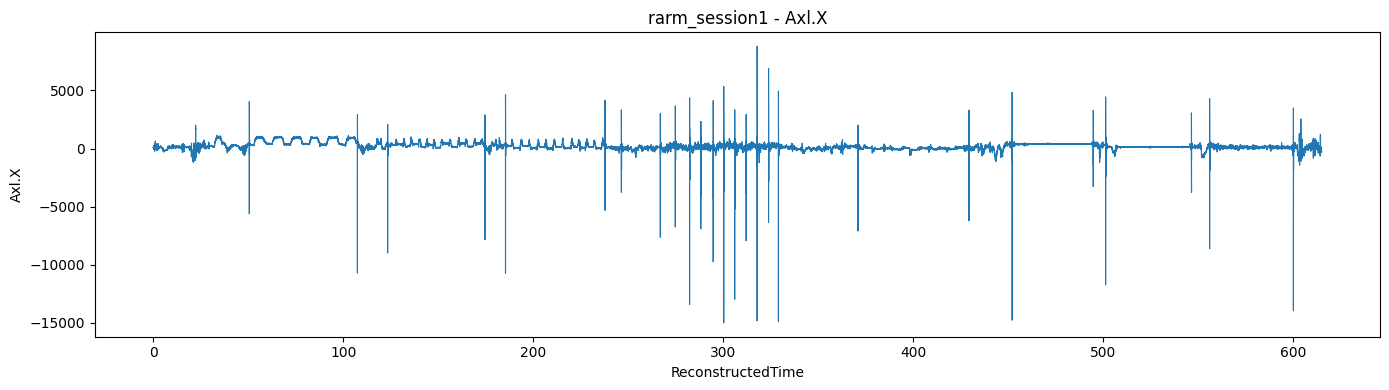

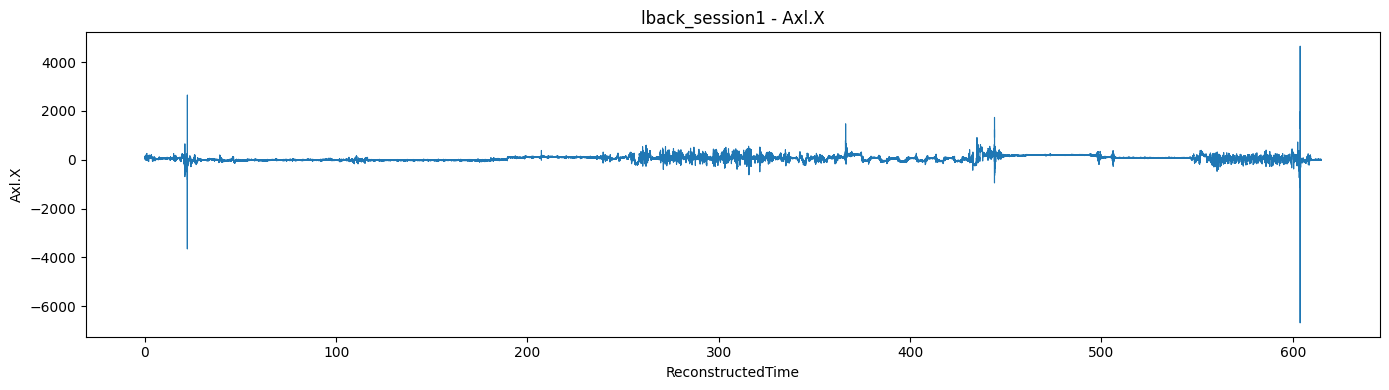

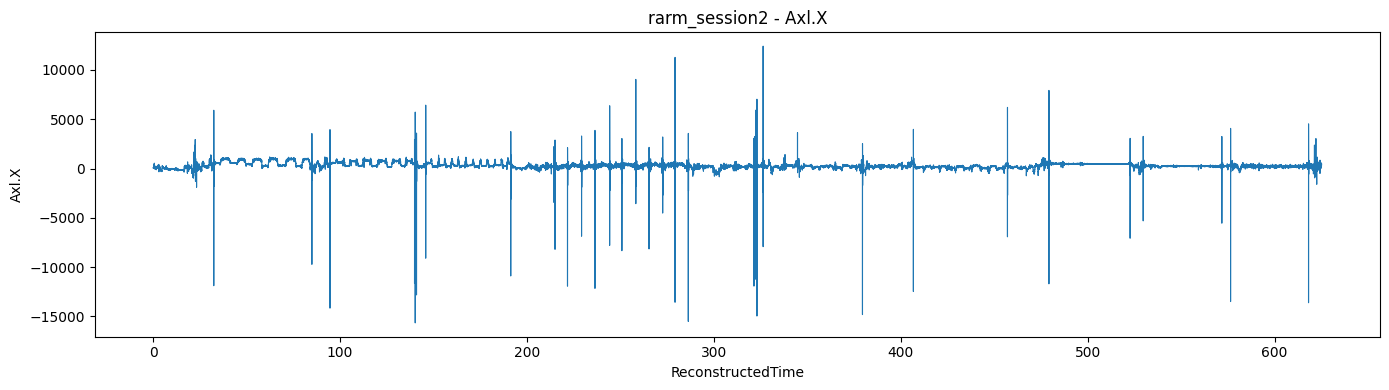

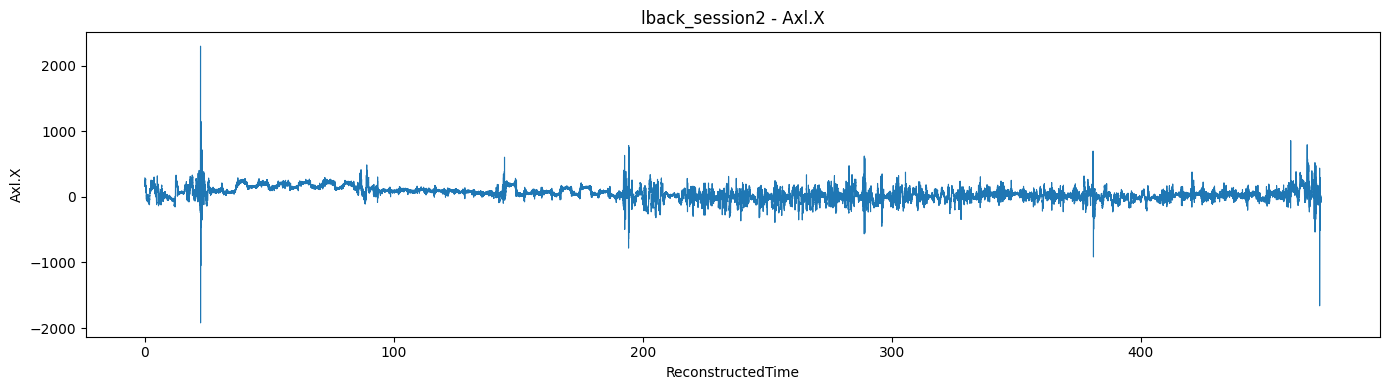

In [15]:

import matplotlib.pyplot as plt

# load reconst time files
df_fixed_rarm1 = pd.read_csv(fixed_time_rarm1)
df_fixed_lback1 = pd.read_csv(fixed_time_lback1)

df_fixed_rarm2 = pd.read_csv(fixed_time_rarm2)
df_fixed_lback2 = pd.read_csv(fixed_time_lback2)

fixed_time_dfs = {
    "rarm_session1": df_fixed_rarm1,
    "lback_session1": df_fixed_lback1,
    "rarm_session2": df_fixed_rarm2,
    "lback_session2": df_fixed_lback2,
}

for name, df in fixed_time_dfs.items():

    plt.figure(figsize=(14, 4))

    plt.plot(
        df["ReconstructedTime"],
        df["Axl.X"],
        linewidth=0.8
    )
    

    plt.title(f"{name} - Axl.X")
    plt.xlabel("ReconstructedTime")
    plt.ylabel("Axl.X")

    plt.tight_layout()
    plt.show()

In [17]:
# number of valid samples before lower back cutout
n_samples = len(df_fixed_lback2)

print("Using sample cutoff:", n_samples)

# crop all session 2 dfs to same sample count
df_fixed_rarm2_crop = df_fixed_rarm2.iloc[:n_samples].copy()
df_fixed_lback2_crop = df_fixed_lback2.iloc[:n_samples].copy()

# optional soles
df_fixed_lsole2_crop = df_time_left2.iloc[:n_samples//8].copy()
df_fixed_rsole2_crop = df_time_right2.iloc[:n_samples//8].copy()

# sanity check
print("rarm2 cropped len :", len(df_fixed_rarm2_crop))
print("lback2 cropped len:", len(df_fixed_lback2_crop))

Using sample cutoff: 378068
rarm2 cropped len : 378068
lback2 cropped len: 378068


In [18]:
# --------------------------------------------------
# Merge session 2 crop + session 1 tail
# Session 1 tail starts after ReconstructedTime > 350
# All session 1 tails are shifted to continue after session 2
# --------------------------------------------------

cut_time_s1 = 350

# -----------------------------
# 1. Keep session 1 tails
# -----------------------------
df_fixed_rarm1_tail = df_fixed_rarm1[
    df_fixed_rarm1["ReconstructedTime"] > cut_time_s1
].copy()

df_fixed_lback1_tail = df_fixed_lback1[
    df_fixed_lback1["ReconstructedTime"] > cut_time_s1
].copy()

df_fixed_lsole1_tail = df_time_left1[
    df_time_left1["ReconstructedTime"] > cut_time_s1
].copy()

df_fixed_rsole1_tail = df_time_right1[
    df_time_right1["ReconstructedTime"] > cut_time_s1
].copy()


# -----------------------------
# 2. Use one shared global offset
#    based on lower-back session 2
# -----------------------------
global_offset = df_fixed_lback2_crop["ReconstructedTime"].iloc[-1]

print("Global offset:", global_offset)

tails = {
    "rarm": df_fixed_rarm1_tail,
    "lback": df_fixed_lback1_tail,
    "lsole": df_fixed_lsole1_tail,
    "rsole": df_fixed_rsole1_tail,
}

for name, df_tail in tails.items():

    old_start = df_tail["ReconstructedTime"].iloc[0]
    old_end = df_tail["ReconstructedTime"].iloc[-1]

    df_tail["ReconstructedTime"] = (
        df_tail["ReconstructedTime"]
        - old_start
        + global_offset
    )

    print(
        f"{name}: old time {old_start:.3f}–{old_end:.3f} "
        f"-> new time {df_tail['ReconstructedTime'].iloc[0]:.3f}–{df_tail['ReconstructedTime'].iloc[-1]:.3f}"
    )


# -----------------------------
# 3. Merge session 2 crop + shifted session 1 tail
# -----------------------------
df_fixed_rarm_merged = pd.concat(
    [df_fixed_rarm2_crop, df_fixed_rarm1_tail],
    ignore_index=True
)

df_fixed_lback_merged = pd.concat(
    [df_fixed_lback2_crop, df_fixed_lback1_tail],
    ignore_index=True
)

df_fixed_lsole_merged = pd.concat(
    [df_fixed_lsole2_crop, df_fixed_lsole1_tail],
    ignore_index=True
)

df_fixed_rsole_merged = pd.concat(
    [df_fixed_rsole2_crop, df_fixed_rsole1_tail],
    ignore_index=True
)


# -----------------------------
# 4. Sanity checks
# -----------------------------
merged_dfs = {
    "rarm": df_fixed_rarm_merged,
    "lback": df_fixed_lback_merged,
    "lsole": df_fixed_lsole_merged,
    "rsole": df_fixed_rsole_merged,
}

print("\nMerged file checks:")
for name, df in merged_dfs.items():
    print(
        f"{name:6} len={len(df):8d} "
        f"time={df['ReconstructedTime'].iloc[0]:.3f}–{df['ReconstructedTime'].iloc[-1]:.3f} "
        f"monotonic={df['ReconstructedTime'].is_monotonic_increasing}"
    )

Global offset: 472.58375
rarm: old time 350.001–614.859 -> new time 472.584–737.441
lback: old time 350.001–614.864 -> new time 472.584–737.446
lsole: old time 350.003–614.747 -> new time 472.584–737.328
rsole: old time 350.002–614.551 -> new time 472.584–737.132

Merged file checks:
rarm   len=  589955 time=0.000–737.441 monotonic=True
lback  len=  589959 time=0.000–737.446 monotonic=True
lsole  len=   74386 time=0.000–737.328 monotonic=True
rsole  len=   74366 time=0.000–737.132 monotonic=True


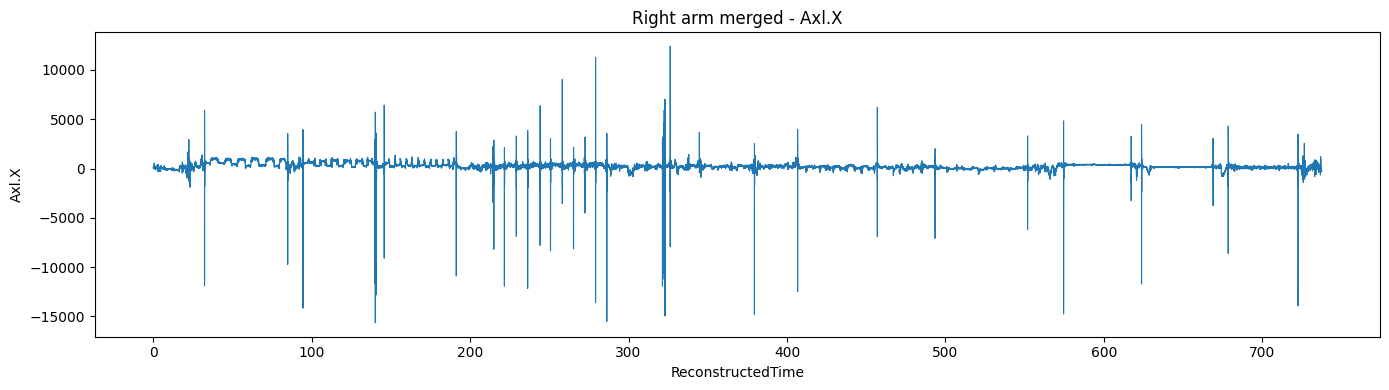

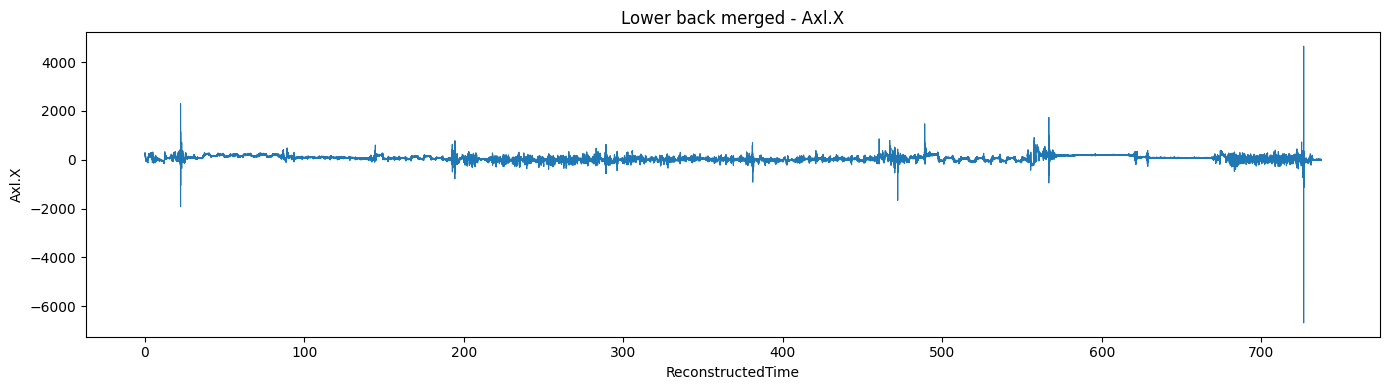

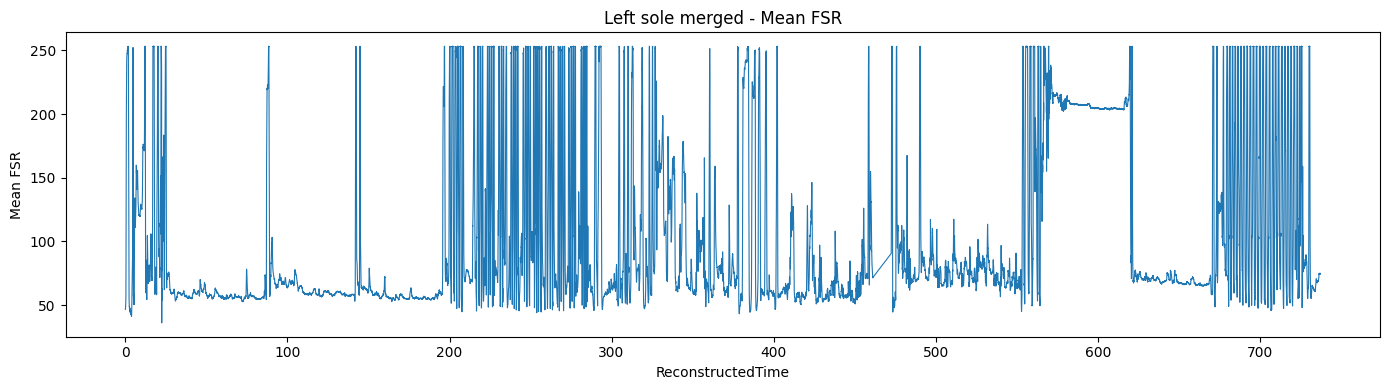

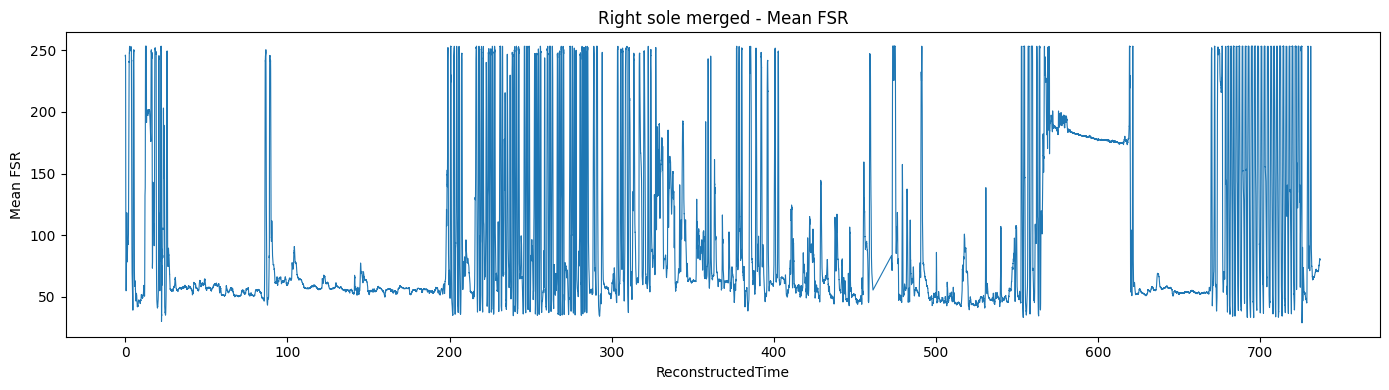

In [19]:
# --------------------------------------------------
# compute mean FSR for soles
# --------------------------------------------------
for df in [df_fixed_lsole_merged, df_fixed_rsole_merged]:

    fsr_cols = [
        c for c in df.columns
        if c.startswith("Fsr")
    ]

    df["FSR_mean"] = df[fsr_cols].mean(axis=1)

# --------------------------------------------------
# RIGHT ARM
# --------------------------------------------------
plt.figure(figsize=(14, 4))

plt.plot(
    df_fixed_rarm_merged["ReconstructedTime"],
    df_fixed_rarm_merged["Axl.X"],
    linewidth=0.8
)

plt.title("Right arm merged - Axl.X")
plt.xlabel("ReconstructedTime")
plt.ylabel("Axl.X")

plt.tight_layout()
plt.show()

# --------------------------------------------------
# LOWER BACK
# --------------------------------------------------
plt.figure(figsize=(14, 4))

plt.plot(
    df_fixed_lback_merged["ReconstructedTime"],
    df_fixed_lback_merged["Axl.X"],
    linewidth=0.8
)

plt.title("Lower back merged - Axl.X")
plt.xlabel("ReconstructedTime")
plt.ylabel("Axl.X")

plt.tight_layout()
plt.show()

# --------------------------------------------------
# LEFT SOLE
# --------------------------------------------------
plt.figure(figsize=(14, 4))

plt.plot(
    df_fixed_lsole_merged["ReconstructedTime"],
    df_fixed_lsole_merged["FSR_mean"],
    linewidth=0.8
)

plt.title("Left sole merged - Mean FSR")
plt.xlabel("ReconstructedTime")
plt.ylabel("Mean FSR")

plt.tight_layout()
plt.show()

# --------------------------------------------------
# RIGHT SOLE
# --------------------------------------------------
plt.figure(figsize=(14, 4))

plt.plot(
    df_fixed_rsole_merged["ReconstructedTime"],
    df_fixed_rsole_merged["FSR_mean"],
    linewidth=0.8
)

plt.title("Right sole merged - Mean FSR")
plt.xlabel("ReconstructedTime")
plt.ylabel("Mean FSR")

plt.tight_layout()
plt.show()

In [20]:
save_dict = {
    "rarm_merged.csv": df_fixed_rarm_merged,
    "lback_merged.csv": df_fixed_lback_merged,
    "lsole_merged.csv": df_fixed_lsole_merged,
    "rsole_merged.csv": df_fixed_rsole_merged,
}

for filename, df in save_dict.items():

    save_path = test_directory / filename

    df.to_csv(save_path, index=False)

    print(f"Saved: {save_path}")

Saved: C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_johanne\test_14\rarm_merged.csv
Saved: C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_johanne\test_14\lback_merged.csv
Saved: C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_johanne\test_14\lsole_merged.csv
Saved: C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_johanne\test_14\rsole_merged.csv
